In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../data/Seed_Data.csv')
df.head()

,A,P,C,LK,WK,A_Coef,LKG,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


we only require the area A, and length of the kernel LK so removing other columns....

In [3]:
df = df[['A','LK']]
df.head()

,A,LK
0,15.26,5.763
1,14.88,5.554
2,14.29,5.291
3,13.84,5.324
4,16.14,5.658


visualise the dataset by plotting A vs LK values...

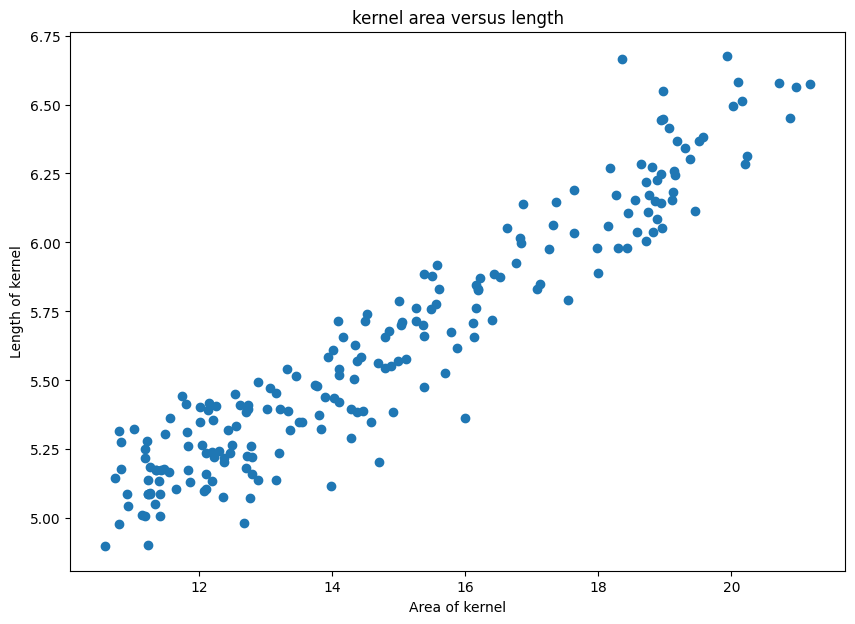

In [4]:
plt.figure(figsize=(10,7))
plt.scatter(df['A'], df['LK'])
plt.xlabel('Area of kernel')
plt.ylabel('Length of kernel')
plt.title('kernel area versus length')
plt.show()

In [5]:
df.mean()

A     14.847524
LK     5.628533
dtype: float64

In [6]:
df.values

array([[15.26 ,  5.763],
       [14.88 ,  5.554],
       [14.29 ,  5.291],
       [13.84 ,  5.324],
       [16.14 ,  5.658],
       [14.38 ,  5.386],
       [14.69 ,  5.563],
       [14.11 ,  5.42 ],
       [16.63 ,  6.053],
       [16.44 ,  5.884],
       [15.26 ,  5.714],
       [14.03 ,  5.438],
       [13.89 ,  5.439],
       [13.78 ,  5.479],
       [13.74 ,  5.482],
       [14.59 ,  5.351],
       [13.99 ,  5.119],
       [15.69 ,  5.527],
       [14.7  ,  5.205],
       [12.72 ,  5.226],
       [14.16 ,  5.658],
       [14.11 ,  5.52 ],
       [15.88 ,  5.618],
       [12.08 ,  5.099],
       [15.01 ,  5.789],
       [16.19 ,  5.833],
       [13.02 ,  5.395],
       [12.74 ,  5.395],
       [14.11 ,  5.541],
       [13.45 ,  5.516],
       [13.16 ,  5.454],
       [15.49 ,  5.757],
       [14.09 ,  5.717],
       [13.94 ,  5.585],
       [15.05 ,  5.712],
       [16.12 ,  5.709],
       [16.2  ,  5.826],
       [17.08 ,  5.832],
       [14.8  ,  5.656],
       [14.28 ,  5.397],


In [7]:
np.mean(df.values, axis=0)

array([14.84752381,  5.62853333])

In [8]:
df.std()

A     2.909699
LK    0.443063
dtype: float64

In [9]:
np.std(df.values, axis=0)

array([2.90276331, 0.44200731])

In [10]:
df.var()

A     8.466351
LK    0.196305
dtype: float64

In [11]:
np.var(df.values, axis=0)

array([8.42603482, 0.19537046])

In [12]:
# compute the covariance matrix...
df.cov()

,A,LK
A,8.466351,1.224704
LK,1.224704,0.196305


In [13]:
# covariance using numpy
np.cov(df.values.T)

array([[8.46635078, 1.22470367],
       [1.22470367, 0.19630525]])

In [14]:
df.values.T.shape

(2, 210)

eigen values and eigen vectors...

any square matrix A of dimension nxn has a vector, x , of shape nx1, in such a way that satisfies the following relation:

- <img src='../../resource_images/Screenshot 2026-03-04 at 05.42.11.png'/>


Alternative representation:

- <img src='../../resource_images/Screenshot 2026-03-04 at 05.43.26.png'/>

- Covariance matrix (A): matrix must be square before undergoing eigen value decomposition. dataset is originally (mxn) not square. to perform eigen decomposition directly, it is first converted to a square matrix A. by using the covariance matrix. of shape nxn.

- Eigen vectors (U) -> each eigen vector describes some amount of variability in the dataset. the variability is indicated by the corresponding eigenvalue. the largetr the eigenvalue, the greater its contribution. An eigen vectors matrix has a shape of nxn. 
- Eigen values (sum sign) - eigen values are the individual values that describe how much contribution each eigenvector provides to the dataset. as described the single eigen vector that describes the largest contributionis referred to as the principal component, andm as such will have the largest eigen value. accordingly, the eigenvector with the smallest eigenvalue contributes the least amount of variance or information to the data. Eigenvalues are a diagonal matrix which has the diagonal elements representing the eignevalues.

- difference between this and SVD is SVD can be done for a rectangular matrix as well..

**Computing eigenvectors and eigenvalues:**

In [15]:
eigenvalues, eigenvectors = np.linalg.eig(np.cov(df.values.T))

note the use of the square covariance matrix above....

In [16]:
eigenvalues

array([8.64390408, 0.01875194])

look at the eigenvalues, and we can see that the first is the largest, so the first eigenvector contributes the most information... 

it is handy to look at eigenvalues as a percentage of the total variance within the dataset. 

In [17]:
eigenvalues2 = np.cumsum(eigenvalues)
eigenvalues2

array([8.64390408, 8.66265602])

In [18]:
# divide by the last or maximum value to convert the eigenvalues to a percentage
eigenvalues2 /= eigenvalues2.max()
eigenvalues2

array([0.99783531, 1.        ])

 the first (principle component) comprises of 99% of the variation within the data, and is therefore the most informative...

In [19]:
eigenvectors

array([[ 0.98965371, -0.14347657],
       [ 0.14347657,  0.98965371]])

shape of the eigenvector matrix is (nxn). i.e. 2x2 in this case since we had 2 features///

so, from the eigenvalues, we saw that the principal component was the first eigenvector. look at the values of the first eigenvector:

In [20]:
eigenvectors[0]

array([ 0.98965371, -0.14347657])

we have decomposed the dataset into the principal components using the eigenvectors and we can further reduce the dimensionality of the data now...

**The Process of PCA:**
- import the required python packages 
- load the entire dataset
- from the available data, select the features you wish to use in dimensionality reduction:
  - if there is a significant difference in the scale between the features of the dataset - may need to normalize one of the features 
- compute the covariance matrix of the selected and normalised data
- compute the eigenvalues and eigenvectors of the covariance matrix
- sort the eigenvalues (and corresponding eigenvectors) fromn the highest to the lowest
- compute the eigenvalues as a percentage of the total variance within the dataset
- select the number of eigenvalues and the corresponding eigenvectors. these will be required to comprise a predetermined value of minimum composition variance
- multiply the dataset by the selected eigenvectors and that is PCA completed. thereby reducing gthe number of features representing the data...

**Manually Execuring PCA:**
- task: we will be computing pca manually, using the same dataset and we want to reduce the number of dimensions within the dataset to comprise at least 75% of the available variance...

In [21]:
df.head()

,A,LK
0,15.26,5.763
1,14.88,5.554
2,14.29,5.291
3,13.84,5.324
4,16.14,5.658


compute the covariance matrix for the selected data. Note when using numpy we need to take the transpose to ensure the matrix is based on the number of features (2) and not the number of samples (150)

In [22]:
data = np.cov(df.values.T)
"""
 The transpose is required to ensure the covariance matrix is based on features, not sampled data
"""
data

array([[8.46635078, 1.22470367],
       [1.22470367, 0.19630525]])

In [23]:
eigenvalues, eigenvectors = np.linalg.eig(data)

In [24]:
eigenvalues

array([8.64390408, 0.01875194])

compute the eigenvectors and eigenvalues for the covariance matrix.....again, use the full

In [25]:
eigenvectors

array([[ 0.98965371, -0.14347657],
       [ 0.14347657,  0.98965371]])

compute the eigenvalues as a percentage of the variance within the dataset...

In [26]:
eigenvalues = np.cumsum(eigenvalues)
eigenvalues /= eigenvalues.max()
eigenvalues

array([0.99783531, 1.        ])

as per the introduction to this exercise, we only to describe the data wutg at least 75% of the available variance. as seen above the first eigenvector (principal component) comprises 99% of the available variance. as such we require only this component from the dataset

In [32]:
reducer = eigenvectors[0]
reducer = reducer.reshape(-1,1)
x_t_p = df.values.dot(reducer)

now, we can apply the dimensionality reduction process.... execute a matrix multiplication of the principal component with the transpose of the dataset

In [33]:
x_t_p.shape

(210, 1)

In [ ]:
x_t_p

array([[14.27526018],
       [13.92917837],
       [13.38301702],
       [12.93293812],
       [15.16122048],
       [13.45845558],
       [13.73985287],
       [13.18637087],
       [15.58947756],
       [15.42569089],
       [14.28229053],
       [13.10461599],
       [12.965921  ],
       [12.85132003],
       [12.81130345],
       [13.67130454],
       [13.11079887],
       [14.73467174],
       [13.80111402],
       [11.83858666],
       [13.20170613],
       [13.17202321],
       [14.90964958],
       [11.22342981],
       [14.02411636],
       [15.18559477],
       [12.11123524],
       [11.8341322 ],
       [13.1690102 ],
       [12.51942567],
       [12.24132164],
       [14.50374139],
       [13.12396525],
       [12.9944561 ],
       [14.0747502 ],
       [15.1341101 ],
       [15.19649564],
       [16.06653005],
       [13.83537146],
       [13.35791196],
       [12.63259857],
       [12.59258199],
       [12.28666024],
       [14.49642074],
       [14.15321181],
       [12

plot the values of the principal component..

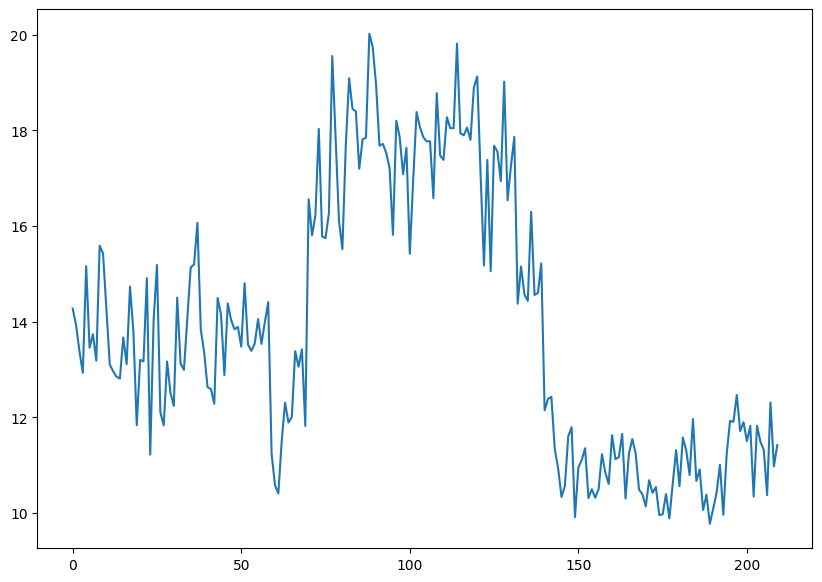

In [50]:
plt.figure(figsize=(10,7))
plt.plot(x_t_p)

we simply computed the covariance matrix w/o applying any transformations beforehand.. if the 2 features have roughly the same mean and standard dev, thats fine but if one of the features is much larger, that may dominate the other when decomposing into components...this could have the effect of removing the information provided by the smaller feature altogether. One simple normalization technique before computing the covariance matrix would be to subtract the respective means from the features thus centering the dataset around zero. 

sklearn pca:

In [37]:
from sklearn.decomposition import PCA

fit the data to a scikit-learn PCA model of the covariance data. use the default vals ..

In [38]:
model = PCA()
model.fit(df.values)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [ ]:
model.explained_variance_ # display the eigen values

array([8.64390408, 0.01875194])

In [40]:
model.explained_variance_ratio_

array([0.99783531, 0.00216469])

In [41]:
# display the eigen vectors via the components_ property:
model.components_

array([[ 0.98965371,  0.14347657],
       [-0.14347657,  0.98965371]])

we will again use only the primary component, so we will create a new pca model, this time specifying the number of components (eigenvectors/eigenvalues) to be 1

In [42]:
model = PCA(n_components=1)

In [43]:
# use the fit method to fit the covariance matrix to the PCA model and generate the corresponding eigenvalues/eigenvectors
model.fit(df.values)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",1
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [ ]:
model.explained_variance_ # the selected eigenvalue...

array([8.64390408])

In [ ]:
model.explained_variance_ratio_ # the variance of the eigen vector being used in comparison to the other vectors...

array([0.99783531])

In [ ]:
model.components_ # eigenvector to be used

array([[0.98965371, 0.14347657]])

transform the seeds dataset into the lower space using the transform mtd

In [47]:
data_t = model.transform(df.values)

In [48]:
data_t.shape

(210, 1)

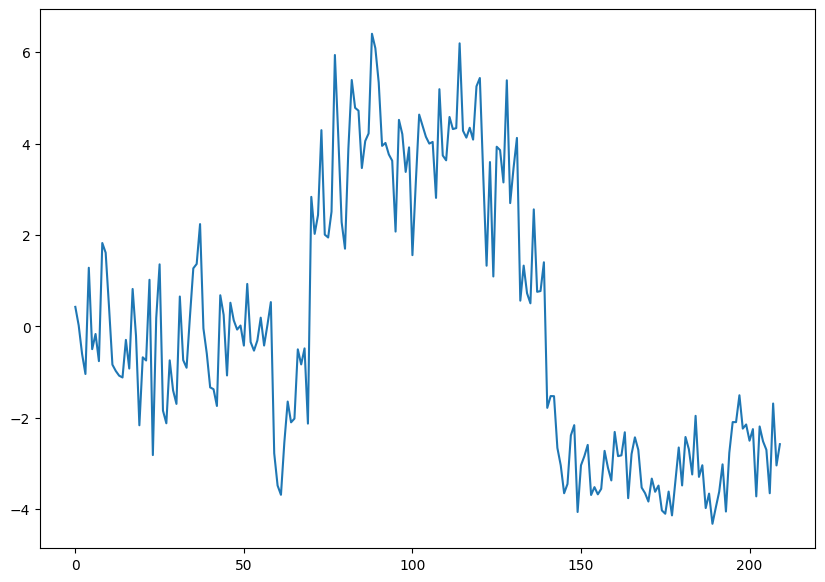

In [49]:
plt.figure(figsize=(10,7))
plt.plot(data_t)

Manual PCA versus Scikit-Learn:
- difference between the 2 plots: the scikit-learn API subtracts the mean of the data prior to the transform....

In [68]:
raw_values = df.values 
raw_values_mean = np.mean(raw_values, axis=0)
# raw_values_std = np.std(raw_values, axis=0)
raw_values_ = (raw_values - raw_values_mean)

In [76]:
raw_values_mean

array([14.84752381,  5.62853333])

In [69]:
raw_values_.shape

(210, 2)

In [70]:
raw_values_cov = np.cov(raw_values_.T)

In [77]:
eigenvectors, eigenvalues, _ = np.linalg.svd(raw_values_cov, full_matrices=False)

In [78]:
eigenvalues

array([8.64390408, 0.01875194])

In [79]:
eigenvectors

array([[-0.98965371, -0.14347657],
       [-0.14347657,  0.98965371]])

In [80]:
transformed_data = raw_values.dot(eigenvectors[0].reshape(-1,1))

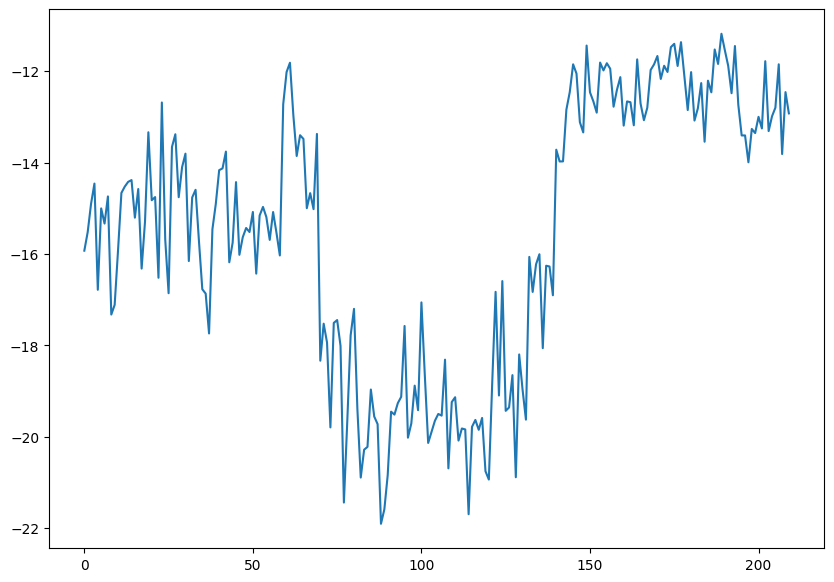

In [81]:
plt.figure(figsize=(10,7))
plt.plot(transformed_data)

visualising variance reduction...

In [83]:
model = PCA(n_components=1)
data_p = model.fit_transform(df.values)

compute the inverse transform of the reduced data and plot the result to visualise the effect of removing variance from the data..

**Singular Value Decomposition:**
- SVD is a factorization method in linalg that decomposes a matriz into 3 other matrices. providing a way to represent data in terms of its singular values..
- SVD helps you split that table into 3 parts: 
  - U: (Tells u about the rows in the data)
  - (sigma) - how important each factor is (how important each col is)
  - Vt - tells you about the products (cols and how similar they are to each other....)

dataset whitening...

dataset whitening:
- tramnsformation to ensure that each feature has a mean of 0, std of 1, and that all features are uncorrelated with each other
- after whitening, the covariance matrix becomes the identity matrix..
- stronger than simple standardization...

In [84]:
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=1, cluster_std=2.5, random_state=1000)
print(np.cov(X.T))

[[6.37258226 0.40799363]
 [0.40799363 6.32083501]]


In [96]:
def zero_center(X):
    return X - np.mean(X, axis=0)

def whiten(X, correct=True):
    Xc = zero_center(X)

    _, L, V = np.linalg.svd(Xc)

    W = np.dot(V.T, np.diag(1.0/L))
    return np.dot(Xc, W) * (np.sqrt(X.shape[0]) if correct else 1.0)

In [99]:
X_whitened = whiten(X, correct=True)

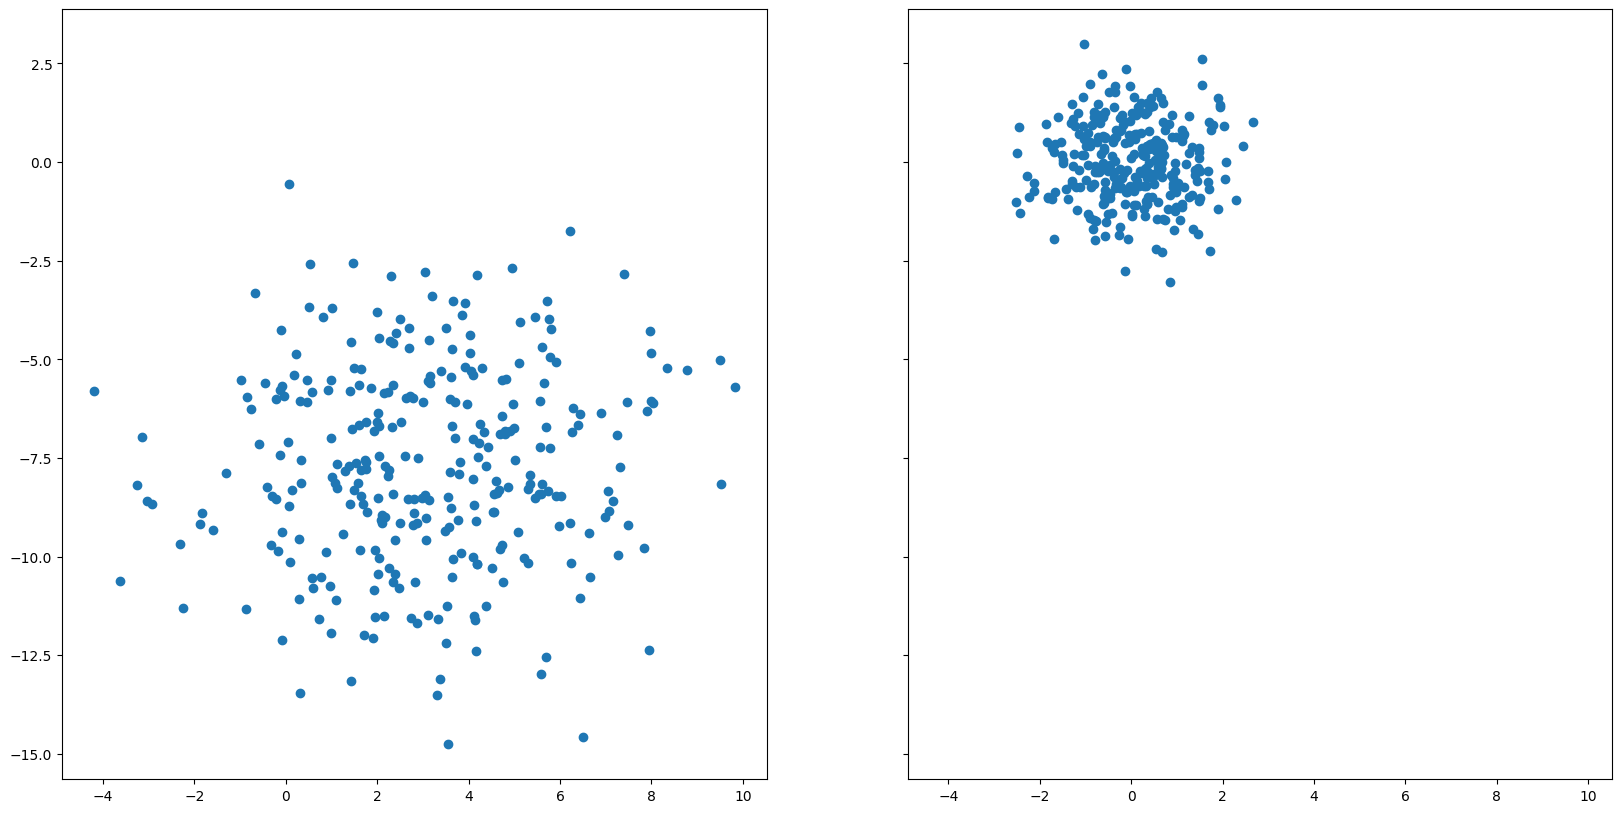

In [100]:
fig, ax = plt.subplots(1,2, figsize=(20,10), sharey=True, sharex=True)
ax[0].scatter(X[:,0], X[:,1])
ax[1].scatter(X_whitened[:,0], X_whitened[:,1])

In [88]:
X.shape

(300, 2)

In [101]:
np.std(X_whitened, axis=0)

array([1., 1.])

In [102]:
np.mean(X_whitened, axis=0)

array([-5.04596365e-16, -4.61482704e-16])

In [103]:
np.cov(X_whitened.T)

array([[ 1.00334448e+00, -8.61443952e-17],
       [-8.61443952e-17,  1.00334448e+00]])

aurelien geron....pca:

In [112]:
from scipy.spatial.transform import Rotation

In [113]:
m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
rng = np.random.default_rng(seed=42)
angles = (rng.random(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * rng.standard_normal((m, 3))  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  # shift a bit

In [114]:
X.shape

(60, 3)

In [115]:
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)

In [116]:
c1 = Vt[0]
c2 = Vt[1]

In [118]:
c1,c2

(array([-0.66824153, -0.73208333, -0.13231495]),
 array([ 0.74374636, -0.66151587, -0.09611511]))

In [123]:
_, ev = np.linalg.eig(np.cov(X_centered.T))
ev[0]

array([ 0.66824153,  0.74374636, -0.01716417])

In [125]:
Vt[:2].shape

(2, 3)

In [121]:
W2 = Vt[:2].T

In [122]:
W2

array([[-0.66824153,  0.74374636],
       [-0.73208333, -0.66151587],
       [-0.13231495, -0.09611511]])

In [126]:
X2D =  X_centered @ W2

In [127]:
s

array([6.74451052, 2.44592561, 1.95304408])

now using sklearn..

In [128]:
from sklearn.decomposition import PCA

In [129]:
pca = PCA(n_components=2)
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [130]:
pca.components_

array([[ 0.66824153,  0.73208333,  0.13231495],
       [ 0.74374636, -0.66151587, -0.09611511]])

In [136]:
pca.explained_variance_ratio_

array([0.82279334, 0.10821224])

choosing the right number of dimensions...

In [137]:
from sklearn.datasets import fetch_openml

Load data:

In [104]:
import pickle, gzip
import os, time

In [144]:
f = gzip.open('../../data/mnist.pkl.gz','rb')

In [145]:
train_set, val_set, test_set = pickle.load(f, encoding='latin1')
f.close()

In [146]:
X_train, y_train = train_set[0], train_set[1]
X_validation, y_validation = val_set[0], val_set[1]
X_test, y_test = test_set[0], test_set[1]

In [147]:
# create pandas dataframes from the datasets..
train_index = range(0,len(X_train))
validation_index = range(len(X_train), \
                            len(X_train)+len(X_validation))
test_index = range(len(X_train)+len(X_validation), \
                            len(X_train)+len(X_validation)+len(X_test))

X_train = pd.DataFrame(data=X_train,index=train_index)
y_train = pd.Series(data=y_train,index=train_index)

X_validation = pd.DataFrame(data=X_validation,index=validation_index)
y_validation = pd.Series(data=y_validation,index=validation_index)

X_test = pd.DataFrame(data=X_test,index=test_index)
y_test = pd.Series(data=y_test,index=test_index)

In [148]:
# display the images:

def view_digit(example):
    label = y_train.loc[example]
    image = X_train.loc[example,:].values.reshape([28,28])
    plt.title(f'Example: {example}. Label: {label}')
    plt.imshow(image, cmap=plt.get_cmap('gray'))
    plt.show()

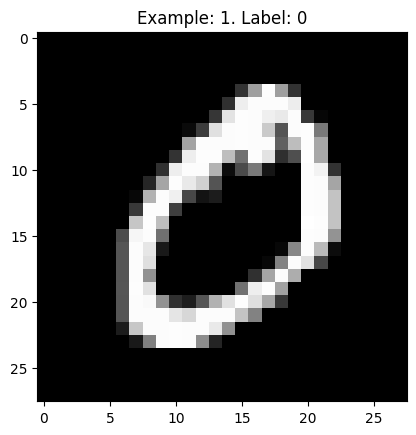

In [153]:
view_digit(1)

pca..choosing the right number of dimensions...

In [ ]:
view_digit

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
49995    0.0
49996    0.0
49997    0.0
49998    0.0
49999    0.0
Name: 0, Length: 50000, dtype: float32

In [154]:
pca = PCA()
pca.fit(X_train.values)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [155]:
pca.explained_variance_ratio_

array([9.74461511e-02, 7.05993846e-02, 6.21621683e-02, 5.37936166e-02,
       4.85763624e-02, 4.31965031e-02, 3.27740945e-02, 2.88638268e-02,
       2.76879668e-02, 2.36592758e-02, 2.09951866e-02, 2.02038419e-02,
       1.71577577e-02, 1.68178249e-02, 1.57926083e-02, 1.49274580e-02,
       1.31816110e-02, 1.27654169e-02, 1.18650338e-02, 1.15101412e-02,
       1.06910355e-02, 1.00749163e-02, 9.53618810e-03, 9.07846913e-03,
       8.82784650e-03, 8.36944580e-03, 8.17534514e-03, 7.84789957e-03,
       7.41995825e-03, 6.90692523e-03, 6.58557191e-03, 6.43648300e-03,
       6.02707500e-03, 5.85296517e-03, 5.69416583e-03, 5.41843008e-03,
       5.07290382e-03, 4.88392776e-03, 4.82046418e-03, 4.73341905e-03,
       4.55972040e-03, 4.41407273e-03, 4.16419003e-03, 3.96214193e-03,
       3.85324447e-03, 3.74056678e-03, 3.61324614e-03, 3.50462995e-03,
       3.40262451e-03, 3.21042771e-03, 3.18192947e-03, 3.10981227e-03,
       2.94566876e-03, 2.88284756e-03, 2.85735773e-03, 2.70755985e-03,
      

In [156]:
cumsum = np.cumsum(pca.explained_variance_ratio_)

In [157]:
cumsum

array([0.09744615, 0.16804554, 0.23020771, 0.28400132, 0.33257768,
       0.37577417, 0.40854827, 0.43741208, 0.46510005, 0.48875934,
       0.50975454, 0.52995837, 0.5471161 , 0.5639339 , 0.5797265 ,
       0.59465396, 0.6078356 , 0.620601  , 0.632466  , 0.64397615,
       0.6546672 , 0.6647421 , 0.6742783 , 0.68335676, 0.6921846 ,
       0.7005541 , 0.70872945, 0.71657735, 0.7239973 , 0.7309042 ,
       0.7374898 , 0.7439263 , 0.7499534 , 0.7558063 , 0.7615005 ,
       0.7669189 , 0.7719918 , 0.77687573, 0.7816962 , 0.78642964,
       0.79098934, 0.7954034 , 0.79956764, 0.8035298 , 0.80738306,
       0.8111236 , 0.81473684, 0.8182415 , 0.8216441 , 0.82485455,
       0.8280365 , 0.8311463 , 0.83409196, 0.8369748 , 0.8398322 ,
       0.8425397 , 0.8452319 , 0.84779555, 0.85033447, 0.8527698 ,
       0.8551747 , 0.85755223, 0.85984355, 0.86206084, 0.8641889 ,
       0.86625654, 0.86829203, 0.87026006, 0.8721887 , 0.87407476,
       0.8759462 , 0.87775755, 0.8795301 , 0.88127637, 0.88292

In [158]:
d = np.argmax(cumsum >= 0.95) + 1

In [159]:
d

np.int64(154)

In [160]:
# instead of finding the optimimum dimensions this way.. could insread pass a float to the n_components param of pca...]
pca = PCA(n_components=0.95) # want to preserve 95% of the variance...

In [161]:
X_reduced = pca.fit_transform(X_train)
pca.n_components_

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow 

np.int64(154)

another option is to plot the explained variance as a function of the number of dimensions...elbow in the curve where the explained variance stops growing fast... in this case, you can see that reducing the dimensionality to about

In [162]:
pca = PCA()

In [163]:
pca.fit(X_train)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [165]:
pca.explained_variance_ratio_.shape

(784,)

the above, explianed_variance_ratio_ => shows the percentage variance of each principal component....

In [166]:
#
var_cumsum = np.cumsum(pca.explained_variance_ratio_)

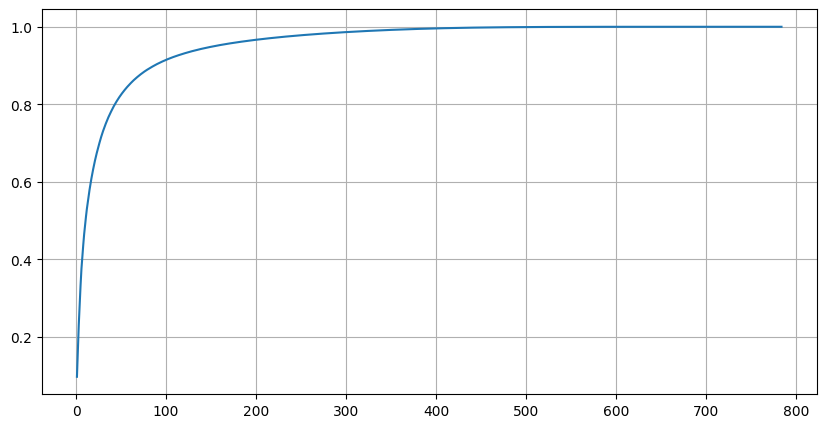

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,5))

ax.plot(np.arange(784)+1, var_cumsum)
ax.grid(True)

notice y - where ~ look for the elbow point where the explained variance stops growing..from above reducing the dimensions down to 100, wouldn't lose too much explained variance...

**PCA for compression:**
- after dimensionality reduction.. the training set takes less space....
- its also possible to decompress the reduced dataset back to 784 dimensions by applying the inverse transformation of the PCA projection
- won't give back the original data since the projection lost information but will likely be close to the original data..
- mean squared distance between the original data and the reconstructed data -> is the reconstruction error..

- the inverse_transform() method lets us decompress the reduced data back to original form....

In [170]:
pca = PCA(n_components=0.95)

X_compressed = pca.fit_transform(X_train)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow 

In [171]:
X_recovered = pca.inverse_transform(X_compressed)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:205: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.components_ + self.mean_
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:205: RuntimeWarning: overflow encountered in matmul
  return X @ self.components_ + self.mean_
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:205: RuntimeWarning: invalid value encountered in matmul
  return X @ self.components_ + self.mean_


reconstructed:

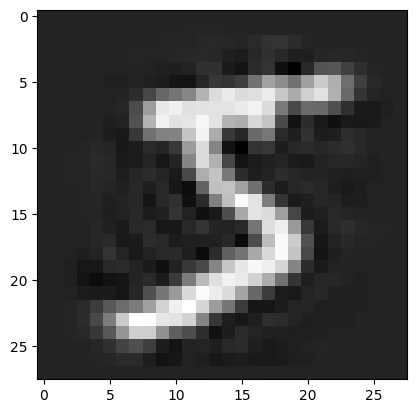

In [175]:
plt.imshow(X_recovered[0].reshape(28,28), cmap='gray')

original:

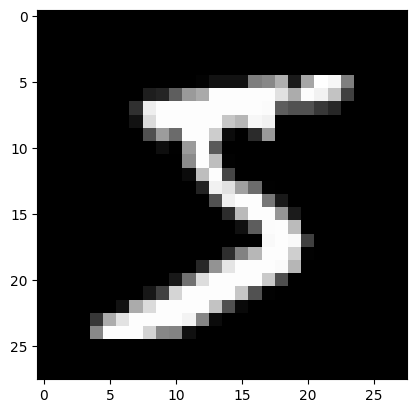

In [182]:
plt.imshow(X_train.iloc[0,:].values.reshape(28,28), cmap='gray')

essentially, the inverse transformation is equal to multiplying the original matrix by the transpose of the reducing vector..

Randomized PCA:
- Setting the svd_solver hyperparameter to 'randomized', scikit-learn uses a stochastic algorithm called randomized pca that quickly finds an approximation of the first d principal components... its computational complexity is simpler than the full pca algorithm...

**Incremental PCA:**
- preceding implementations require the entire training set to fit into memory in order to run..
- fortunately, incremental pca - allows you to split the training into mini-batches and feed these in one mini-batch at a time. 
- useful for large training sets and for applying pca online .

- following code splits the MNIST training set into 100 mini-batches (using numpy's array_split() function) and feeds them to scikit-learn's IncrementalPCA class to reduce the dimensionality of the MNIST dataset 

In [183]:
from sklearn.decomposition import IncrementalPCA

In [184]:
n_batches = 100

In [185]:
inc_pca = IncrementalPCA(n_components=154)

In [187]:
for X_batch in np.array_split(X_train.values, n_batches):
    inc_pca.partial_fit(X_batch)


In [188]:
X_reduced = inc_pca.transform(X_train.values)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:159: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-

In [189]:
for x_batch in np.array_split(X_train.values, n_batches):
    print(x_batch.shape)

(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)
(500, 784)

alternatively, could use numpy's memmap class which allows you to manipulate a large array stored in a binary file on a disk as if it were entirely in memory

**Sparse PCA:**
- Standard PCA is generally a dense decomposition; i.e. the vectors, once transformed, are linear combinations of all the components with not-null coefficients....
- for some ml problems, some degree of sparsity may be preferred. a version of pca that retains some degree of sparsity - controlled by a hyperparameter called alpha - sparse PCA. 
- sparse PCA algorithm searches for linear combinations in just some of the input variables, reducing the original feature space to some degree but not compactly as normal PCA.
- regular PCA explains more variance than sparse PCA
- REGULAR PCA: find the absolute best direction - no constraints
- Sparse PCA: Find the best direction, but it can only use a few features...

- Sparse PCA:
  - INTERPRETABILITY: each component has weights for only a few of the original features-- hence when you reduce dimensions, you know what features essentially make up each principal componment...explainability
  - Feature selection: sparse pca also doubles as a feature selection tool...the features with non-zero loadings in the sparse components are the important ones..
  - noise robustness - regular pca spreads weights across all features including the noisy irrelevant ones. sparse pca can ignore irrelevant features by zeroing them out
  - high dimensional data (p>>n) : if u have more features than samples, - sparse pca acts as a regularization, stabilizing the solution
  - comm
- Sparse pca is controlled by some hyperparam - alpha: alpha = 0 => results in normal pca
- increase in alpha results in increase in the penalty hence high chance that more parts of the component are set to zero...

In [190]:
from sklearn.decomposition import SparsePCA

In [202]:
n_components = 100
alpha = 0.8
random_state = 2026
n_jobs = -1

In [203]:
sparsePCA = SparsePCA(n_components=n_components, alpha=alpha, random_state=random_state, n_jobs=n_jobs)

In [204]:
sparsePCA.fit(X_train)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_dict_learning.py:519: RuntimeWarning: divide by zero encountered in matmul
  A = code.T @ code
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_dict_learning.py:519: RuntimeWarning: overflow encountered in matmul
  A = code.T @ code
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_dict_learning.py:519: RuntimeWarning: invalid value encountered in matmul
  A = code.T @ code
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_dict_learning.py:521: RuntimeWarning: divide by zero encountered in matmul
  B = Y.T @ code
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_dict_

KeyboardInterrupt: 

In [196]:
sparsePCA.components_[0].shape

(784,)

In [201]:
np.argwhere(sparsePCA.components_[99]>0).shape

(329, 1)

485 components..non zero in first component..

Kernel PCA:
- is a non-linear form of pca 
- runs a similarity function over pairs of original data points in order to perform non-linear dim reduction


- for when original data isn't linearly separable..

In [205]:
from sklearn.decomposition import KernelPCA

In [206]:
n_components = 100
kernel = 'rbf'
gamma = None
random_state = 2018
n_jobs = 1

In [207]:
kernelPCA = KernelPCA(n_components=n_components, kernel=kernel, gamma=gamma, n_jobs=n_jobs, random_state=random_state)

In [209]:
kernelPCA.fit(X_train.loc[:10000,:])
x_train_kernelPCA = kernelPCA.transform(X_train)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Docu

- if the data is initially not clearly linearly separable -> use kernel pca
- core idea is if projected to some n-dim space by a kernel then we can separate it easily - project it to some low dim space easily in this case...
- for efficiency for the cov matrix instead of generating an nxn matrix we generate a pxp matrix - to curb dimensions from exploding... in this dot product computation then we apply the kernel to the dot product computed... so this is our cov matrix to which we then apply eigendecomposition..

**Singular Value Decomposition:**
- Another approach to learning the underlying structure of the data is to reduce the rank of the original matrix of features to a smaller rank such that the original matrix can be recreated using a linear combinatioon of some pf the vectors in the smaller rank matrix. (Singular Value Decomposition SVD)
- Is almost the same as PCA though...

For very high dimensional datasets, PCA can be too slow...even if you come down to pca with a randomized solver, the complexity of that is dependent on the number of records (rows), and the target dimensions, d.  So, the target number of dimensions, mustn't be too large. When dealing with with a dataset with tens of thousands of features or more then training may become too slow...
- in this case consider using random projection instead....

**Random Projection:**
- The random projection algorithm projects the data to a lower dimensional spae using a random linear projection.
- Similar concept to PCA but in this case we don't optimize or do some form of eigendecomposition to find the 'reducer' vectors that project the matrix to a lower dimensional space
- Instead, we find a random 'reducer' matrix that projects the input matrix to a lower dimensional space.

Why this works:
- Johnson_lindenstrauss Lemma: For any set of points in high dimensional space, there exists a projection to k = O(logn/Epsilon**2) dimensions that preserves all pairwise distances to within a factor of (1+- epsilon)
- distances between data points are approximately preserved after random projection. not exactly, but within a provable error bound that you can control by setting k to be large enough..

Deep Intuition:
 - In high dimensional spaces, random vectors are always nearly orthogonal to each other. If you draw two random vectors in 1000-dimensional spacem, the angle between them is almost certainly close to 90-degrees.
 - Means that in a random projection matrix, the columns are orthogonal - similar to what PCA gives you but achieved randomly through expensive optimization
 - The randomness averages out - some directions get stretched, some get compressed, but on average distances are preserved. the higher the k is, the better the averaging and the tighter the distance preservation

 PCA cost:
  - must compute the covariance matrix -> (pxp) => brutal when the number of features p is high....
  - must eigen decompose it -> brutal when p is large...
  - generation of reducer matrix is trivial in random projection

Random projection worse than PCA at:
 - maximizing explainable variance
 - interpretability
 - finding the truly most informative directions

better than PCA at:
 - raw speed
 - memory
 - streaming data : can apply to new data instantly no retraining needed
 - very high dimensional data
 - preserving distances

With new data coming in:
- Random projection: R (reducer matrix) - is generated once and is completely independent of your data. So no need to retrain when deployed and is faster and better for streaming...
- PCA: technically needs retraining.... principal components are computed from the data itself... they are the directions of maximum variance in your specific dataset...
- when new data comes in: the covariance structure of the dataset changes... true pricipal components shift... existing W is now sligghtly suboptimal..

In practice:
- just don't retrain: if new data is similar in distribution to the trainign data - old components are still approximately valid...
- Incremental pca: 
- full training: expensive but gives optimal components...


There is an equation for random projection to check and ensur that the minimum number of dimensions is chosen that preserves, with high probability, the distances between the points in the two dimensional spaces...
- equation relies on the number/example of points and the set tolerance...

In [210]:
# equation is implemented by the johnson_lindenstrauss_min_dim() function

from sklearn.random_projection import johnson_lindenstrauss_min_dim

In [227]:
# set the number of examples you have, m, and the set tolerance (min squared distance between points in 2 dimensional spaces)
m, epsilon = 5000, 0.1 # we don't want the squared distance to change more than 10%
d = johnson_lindenstrauss_min_dim(m, eps=epsilon)
d


np.int64(7300)

the fewer the data points you have the lower the allowable dimensional reduction 

now, we can generate a random matrix P, of shape [d,n], where each item is sampled randomly from a Gaussian distribution with mean 0 and variance 1/d...and use it to project a dataset from n dimensions to d:

In [229]:
n = 20_000
rng = np.random.default_rng(seed=42)
P = rng.standard_normal((d, n)) / np.sqrt(d) # std dev = sqrt(variance)

X = rng.standard_normal((m,n)) # generate a fake dataset

X_reduced = X @ P.T

/var/folders/_h/yzv4_kzj2yv3z5xh7lks3hpr0000gn/T/ipykernel_1087/2835741583.py:7: RuntimeWarning: divide by zero encountered in matmul
  X_reduced = X @ P.T
/var/folders/_h/yzv4_kzj2yv3z5xh7lks3hpr0000gn/T/ipykernel_1087/2835741583.py:7: RuntimeWarning: overflow encountered in matmul
  X_reduced = X @ P.T
/var/folders/_h/yzv4_kzj2yv3z5xh7lks3hpr0000gn/T/ipykernel_1087/2835741583.py:7: RuntimeWarning: invalid value encountered in matmul
  X_reduced = X @ P.T


thats all there is to it... its simple... and efficient and training is almost instantaneous... the only thing this algorithm needs is the the dataset's shape initially. the data itself isn't used at all. this makes random projection particularly well suited to very high-dimwensional data.  At inference time -> random projection is as fast as pca. 
Scikit-learn offers a gaussian random projection class to do exaxctly what we just did...

In [230]:
from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=epsilon, random_state=42)

X_reduced = gaussian_rnd_proj.fit_transform(X) # same result as above

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/random_projection.py:612: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/random_projection.py:612: RuntimeWarning: overflow encountered in matmul
  return X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/random_projection.py:612: RuntimeWarning: invalid value encountered in matmul
  return X @ self.components_.T


sklearn also offers the sparse random projection algo...
- determines the target dimensionality in the same way as random proj
- generates a random matrix of the same shape, and performs projection identically
- main difference is that the random matrix is sparse.
- implying it uses less memory
- much faster to generate as well...
- quality of dim reduction is comparable as well... only slightly less accurate
- the ratio r of nonzero items in the sparse random matrix is called its density (By default, eq to 1/sqrt(n))
- one in sqrt(n) is non zero...
- each cell in the sparse matrix has a probability r, of being nonzero and each nonzero value is either -v or v

from sklearn.random_projection import SparseRandomProjection

srp = SparseRandomProjection(
    n_components='auto',
    density='auto',
    eps=0.1,
    dense_output=False,
    random_state=42
)
```

---

**`n_components`** — the target dimension k

- If set to `'auto'`, sklearn uses the JL lemma formula to compute the minimum k needed to satisfy your eps tolerance for your n samples
- If you set it manually (e.g. n_components=300), it overrides eps entirely — you're saying "I want exactly 300 dimensions, JL guarantees be damned"
- This is the same k as in regular random projection

---

**`eps`** — the distortion tolerance ε

- Only used when n_components='auto'
- Controls what distortion you're willing to accept on pairwise distances
- eps=0.1 means distances preserved within 10%
- **Lower eps** → tighter guarantee → higher k required → more dimensions
- **Higher eps** → looser guarantee → lower k → fewer dimensions
- Typical values: 0.1 to 0.5
- This is the ε in the JL formula — the direct lever on the tradeoff between compression and accuracy

---

**`density`** — the fraction of nonzero entries in R (i.e. 1/s)

- Controls how sparse the random matrix is
- If set to `'auto'`, sklearn uses the theoretically optimal value:

$$\text{density} = \frac{1}{\sqrt{p}}$$

where p is your number of input features. This is the Achlioptas recommendation — sparse enough for big speedups, dense enough to still satisfy JL.

- If you set it manually, e.g. density=0.1, exactly 10% of entries in R will be nonzero
- **Lower density** → sparser R → faster computation → less reliable per-direction but JL still holds if not too sparse
- **Higher density** → approaches dense Gaussian projection → slower but more stable per direction
- Valid range: (0, 1]. Setting density=1 gives you a dense ±1 matrix (not Gaussian but still valid)

---

**`dense_output`** — output format

- If False (default), output Z is returned as a sparse matrix if possible
- If True, always returns a dense numpy array
- Only matters computationally — mathematically identical
- Set to True if your downstream algorithm (e.g. sklearn's KMeans) doesn't accept sparse matrices

---

**`random_state`** — reproducibility seed

- Since R is random, setting this ensures you get the same R every run
- Critical for reproducibility — without it, two runs give slightly different projections
- Doesn't affect the mathematical guarantees, just fixes which specific random matrix you use

---

### The Hyperparameter Interactions

The key tradeoff triangle:
```
        eps (distortion tolerance)
            ↕
n_components ←——→ density (sparsity of R)
    (size of Z)      (speed of projection)